In [1]:
import pandas as pd

supply_df = pd.read_csv('../data/processed/transit_supply_index.csv')
need_df = pd.read_csv('../data/processed/transit_need_index.csv')
gap_df = pd.read_csv('../data/processed/transit_gap.csv', index_col='Rank')

In [2]:
var1 = supply_df['Scaled_VRM_per_capita']
var2 = supply_df['Scaled_VRH_per_capita']
var3 = need_df['no_vehicle_pct(Standardized)']
var4 = need_df['transit_commute_pct(Standardized)']
var5 = need_df['z_median_income(Standardized)']

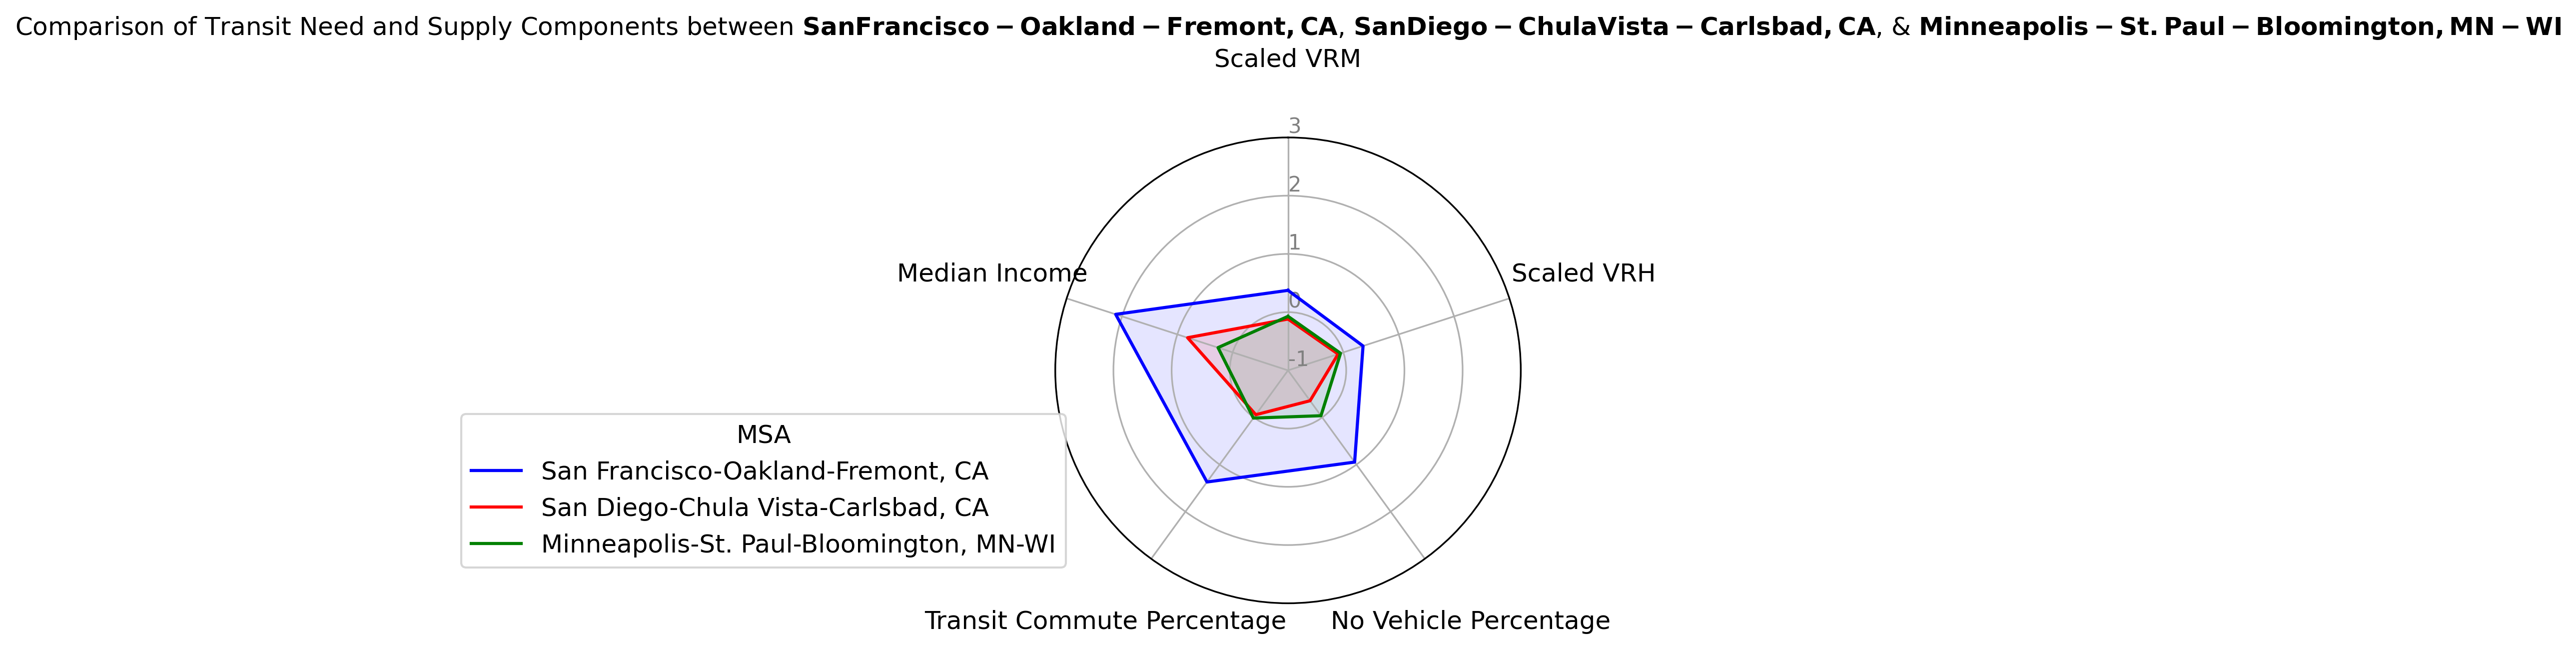

In [11]:
# Libraries
import matplotlib.pyplot as plt
import pandas as pd
from math import pi

df = pd.DataFrame({
    'MSAs': need_df['MSA_Name'],
    'Scaled VRM': var1,
    'Scaled VRH': var2,
    'No Vehicle Percentage': var3,
    'Transit Commute Percentage': var4,
    'Median Income': var5
})

categories = list(df)[1:]  # variable names
N = len(categories)

# What will be the angle of each axis in the plot
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # close the loop

# Initialise the radar chart
plt.figure(figsize=(8,8), dpi=300)
ax = plt.subplot(111, polar=True)

# First axis on top
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# Draw one axis per variable + add labels, move them further away
plt.xticks(angles[:-1], categories, fontsize=12, color='black', rotation=0)
ax.tick_params(pad=27)  # increases distance of variable labels from circle

# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([-1,0,1,2,3,4,5], ["-1","0","1","2","3","4","5"], color="grey", size=10)
plt.ylim(-1,3)


#EDIT THIS - Indices of the MSAs to plot
x1 = 12
x2 = 17
x3 = 15

# Individual 1
values = df.loc[x1].drop('MSAs').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1.5, linestyle='solid', label=df.loc[x1, 'MSAs'], color='blue')
ax.fill(angles, values, color='blue', alpha=0.1)

# Individual 2
values = df.loc[x2].drop('MSAs').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1.5, linestyle='solid', label=df.loc[x2, 'MSAs'], color='red')
ax.fill(angles, values, color='red', alpha=0.1)

# Individual 3
values = df.loc[x3].drop('MSAs').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1.5, linestyle='solid', label=df.loc[x3, 'MSAs'], color='green')
ax.fill(angles, values, color='green', alpha=0.1)

#Legend
plt.legend(loc='lower right', bbox_to_anchor=(0.05, 0.05), fontsize=12, title='MSA', title_fontsize=12)

msa1_name = df.loc[x1, "MSAs"]
msa2_name = df.loc[x2, "MSAs"]
msa3_name = df.loc[x3, "MSAs"]
plt.title(rf"Comparison of Transit Need and Supply Components between $\bf{{{msa1_name}}}$, $\bf{{{msa2_name}}}$, & $\bf{{{msa3_name}}}$")

# Show the graph
plt.tight_layout()
plt.show()


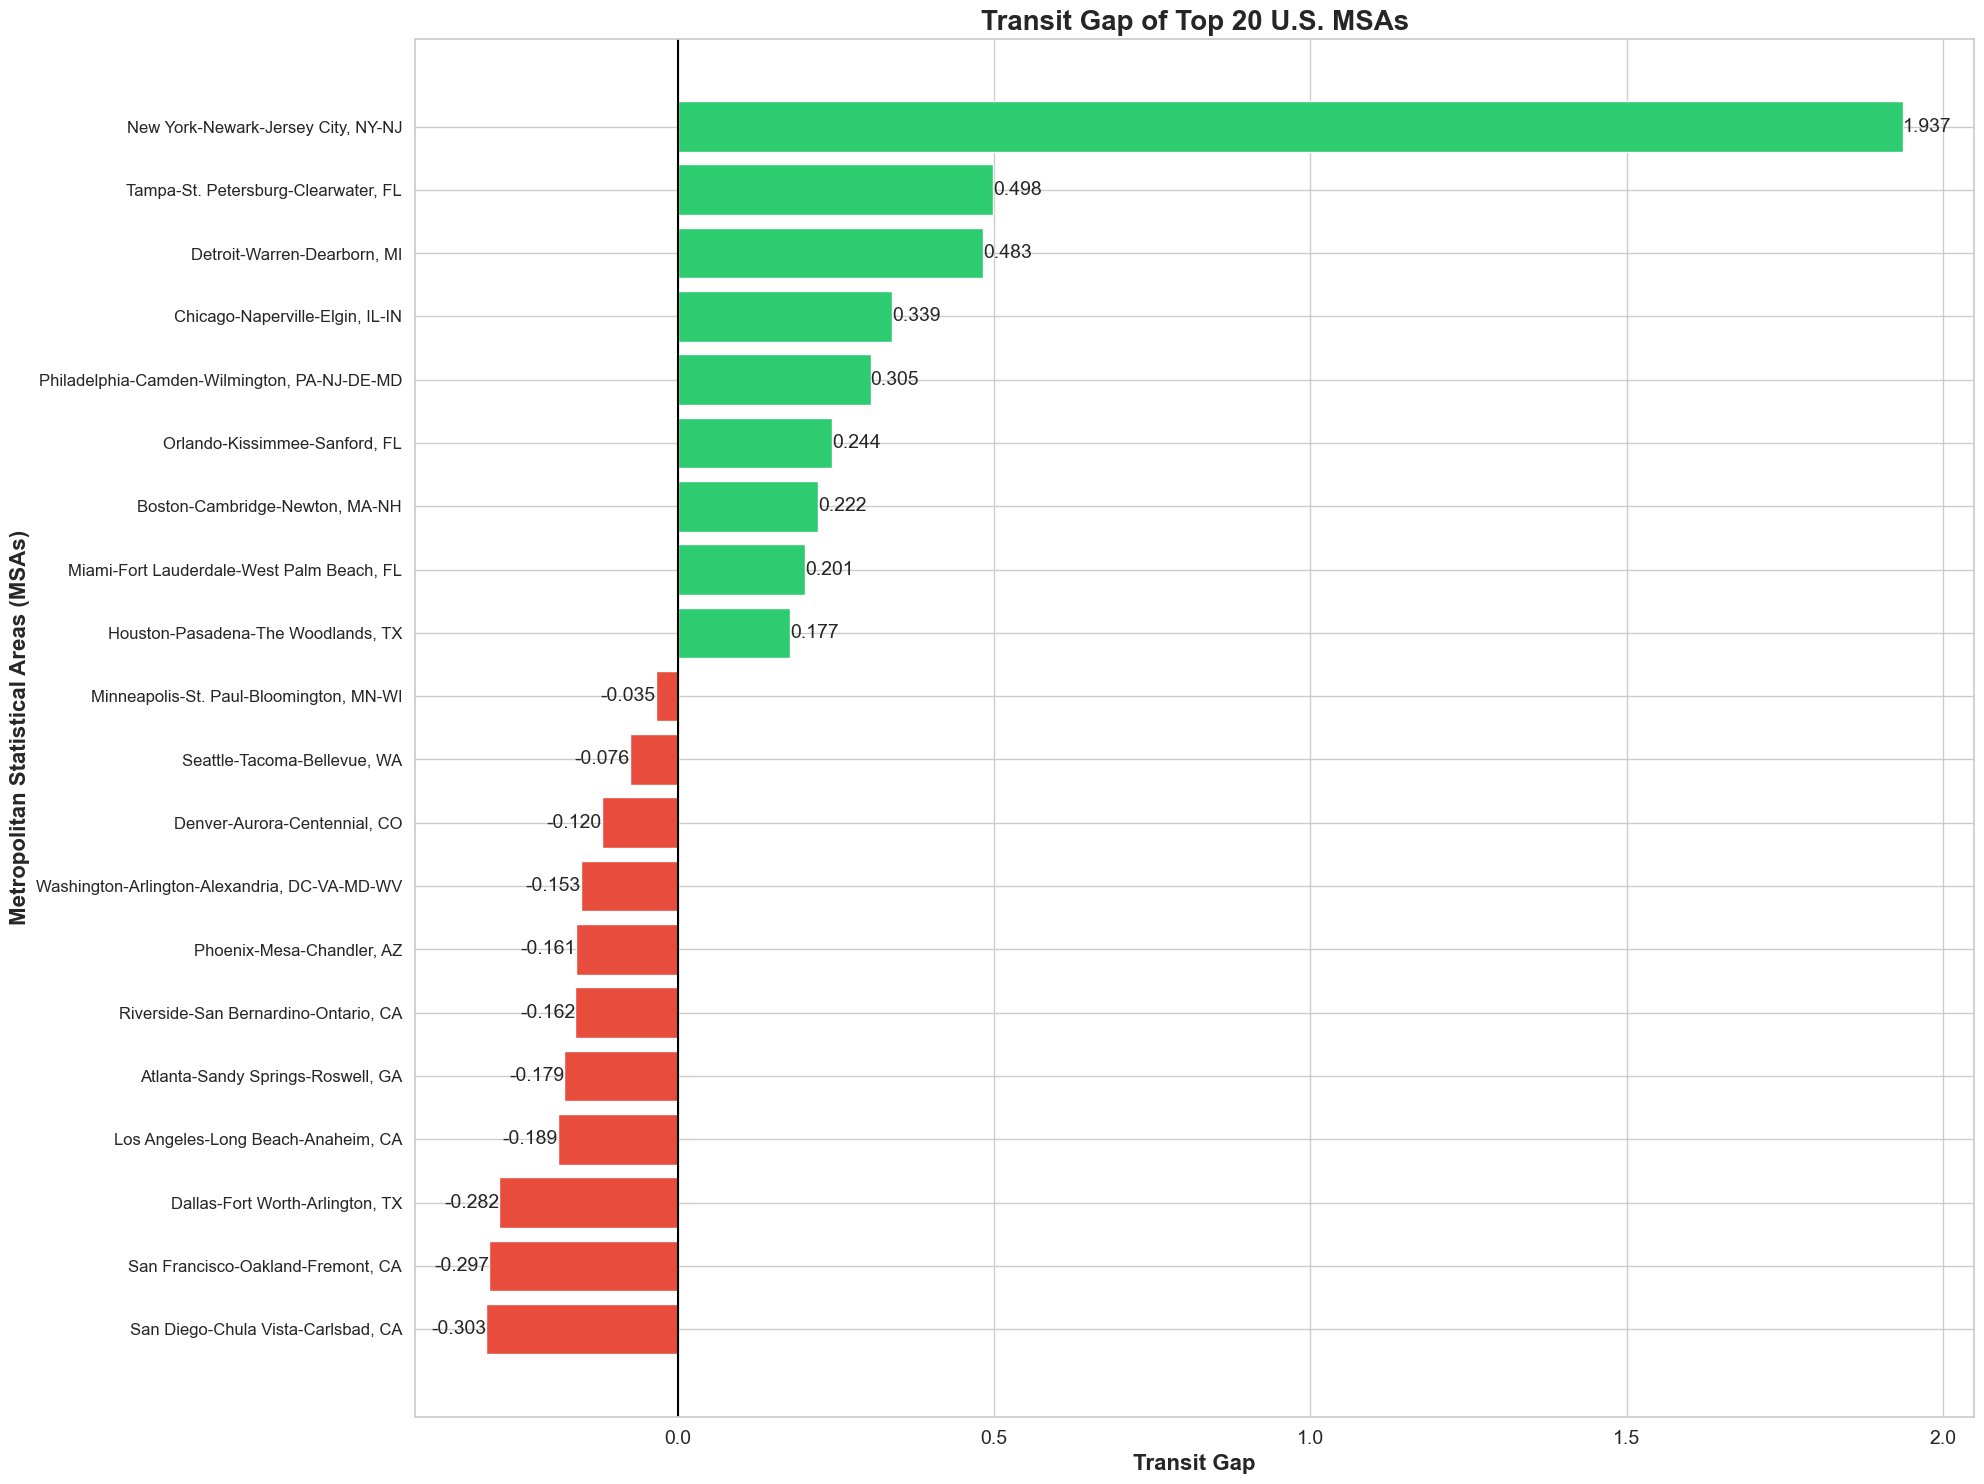

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a sample DataFrame with positive and negative values
result = gap_df.sort_values(by='Transit Gap', ascending=True)
data = {
    'Metropolitan Statistical Areas (MSAs)': result['MSA_Name'],
    'Transit Gap': result['Transit Gap']
}
df = pd.DataFrame(data)

# Set a nice Seaborn style
sns.set_theme(style="whitegrid")

# Create the horizontal bar plot
plt.figure(figsize=(20, 15))
ax = plt.subplot()

# Create color array based on positive/negative values
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in df['Transit Gap']]

# Use barh for horizontal bars with custom colors
ax.barh(df['Metropolitan Statistical Areas (MSAs)'], df['Transit Gap'], color=colors)
ax.bar_label(ax.containers[0], fmt='%.3f', size=14)

# Add title and labels
plt.title('Transit Gap of Top 20 U.S. MSAs', fontsize=20, fontweight='bold')

ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=12)

plt.xlabel('Transit Gap', fontsize=16, fontweight='bold')
plt.ylabel('Metropolitan Statistical Areas (MSAs)', fontsize=16, fontweight='bold')

# Ensure the x-axis crosses at 0 for clarity
plt.axvline(0, color='black', linewidth=1.5)

plt.tight_layout()
plt.show()


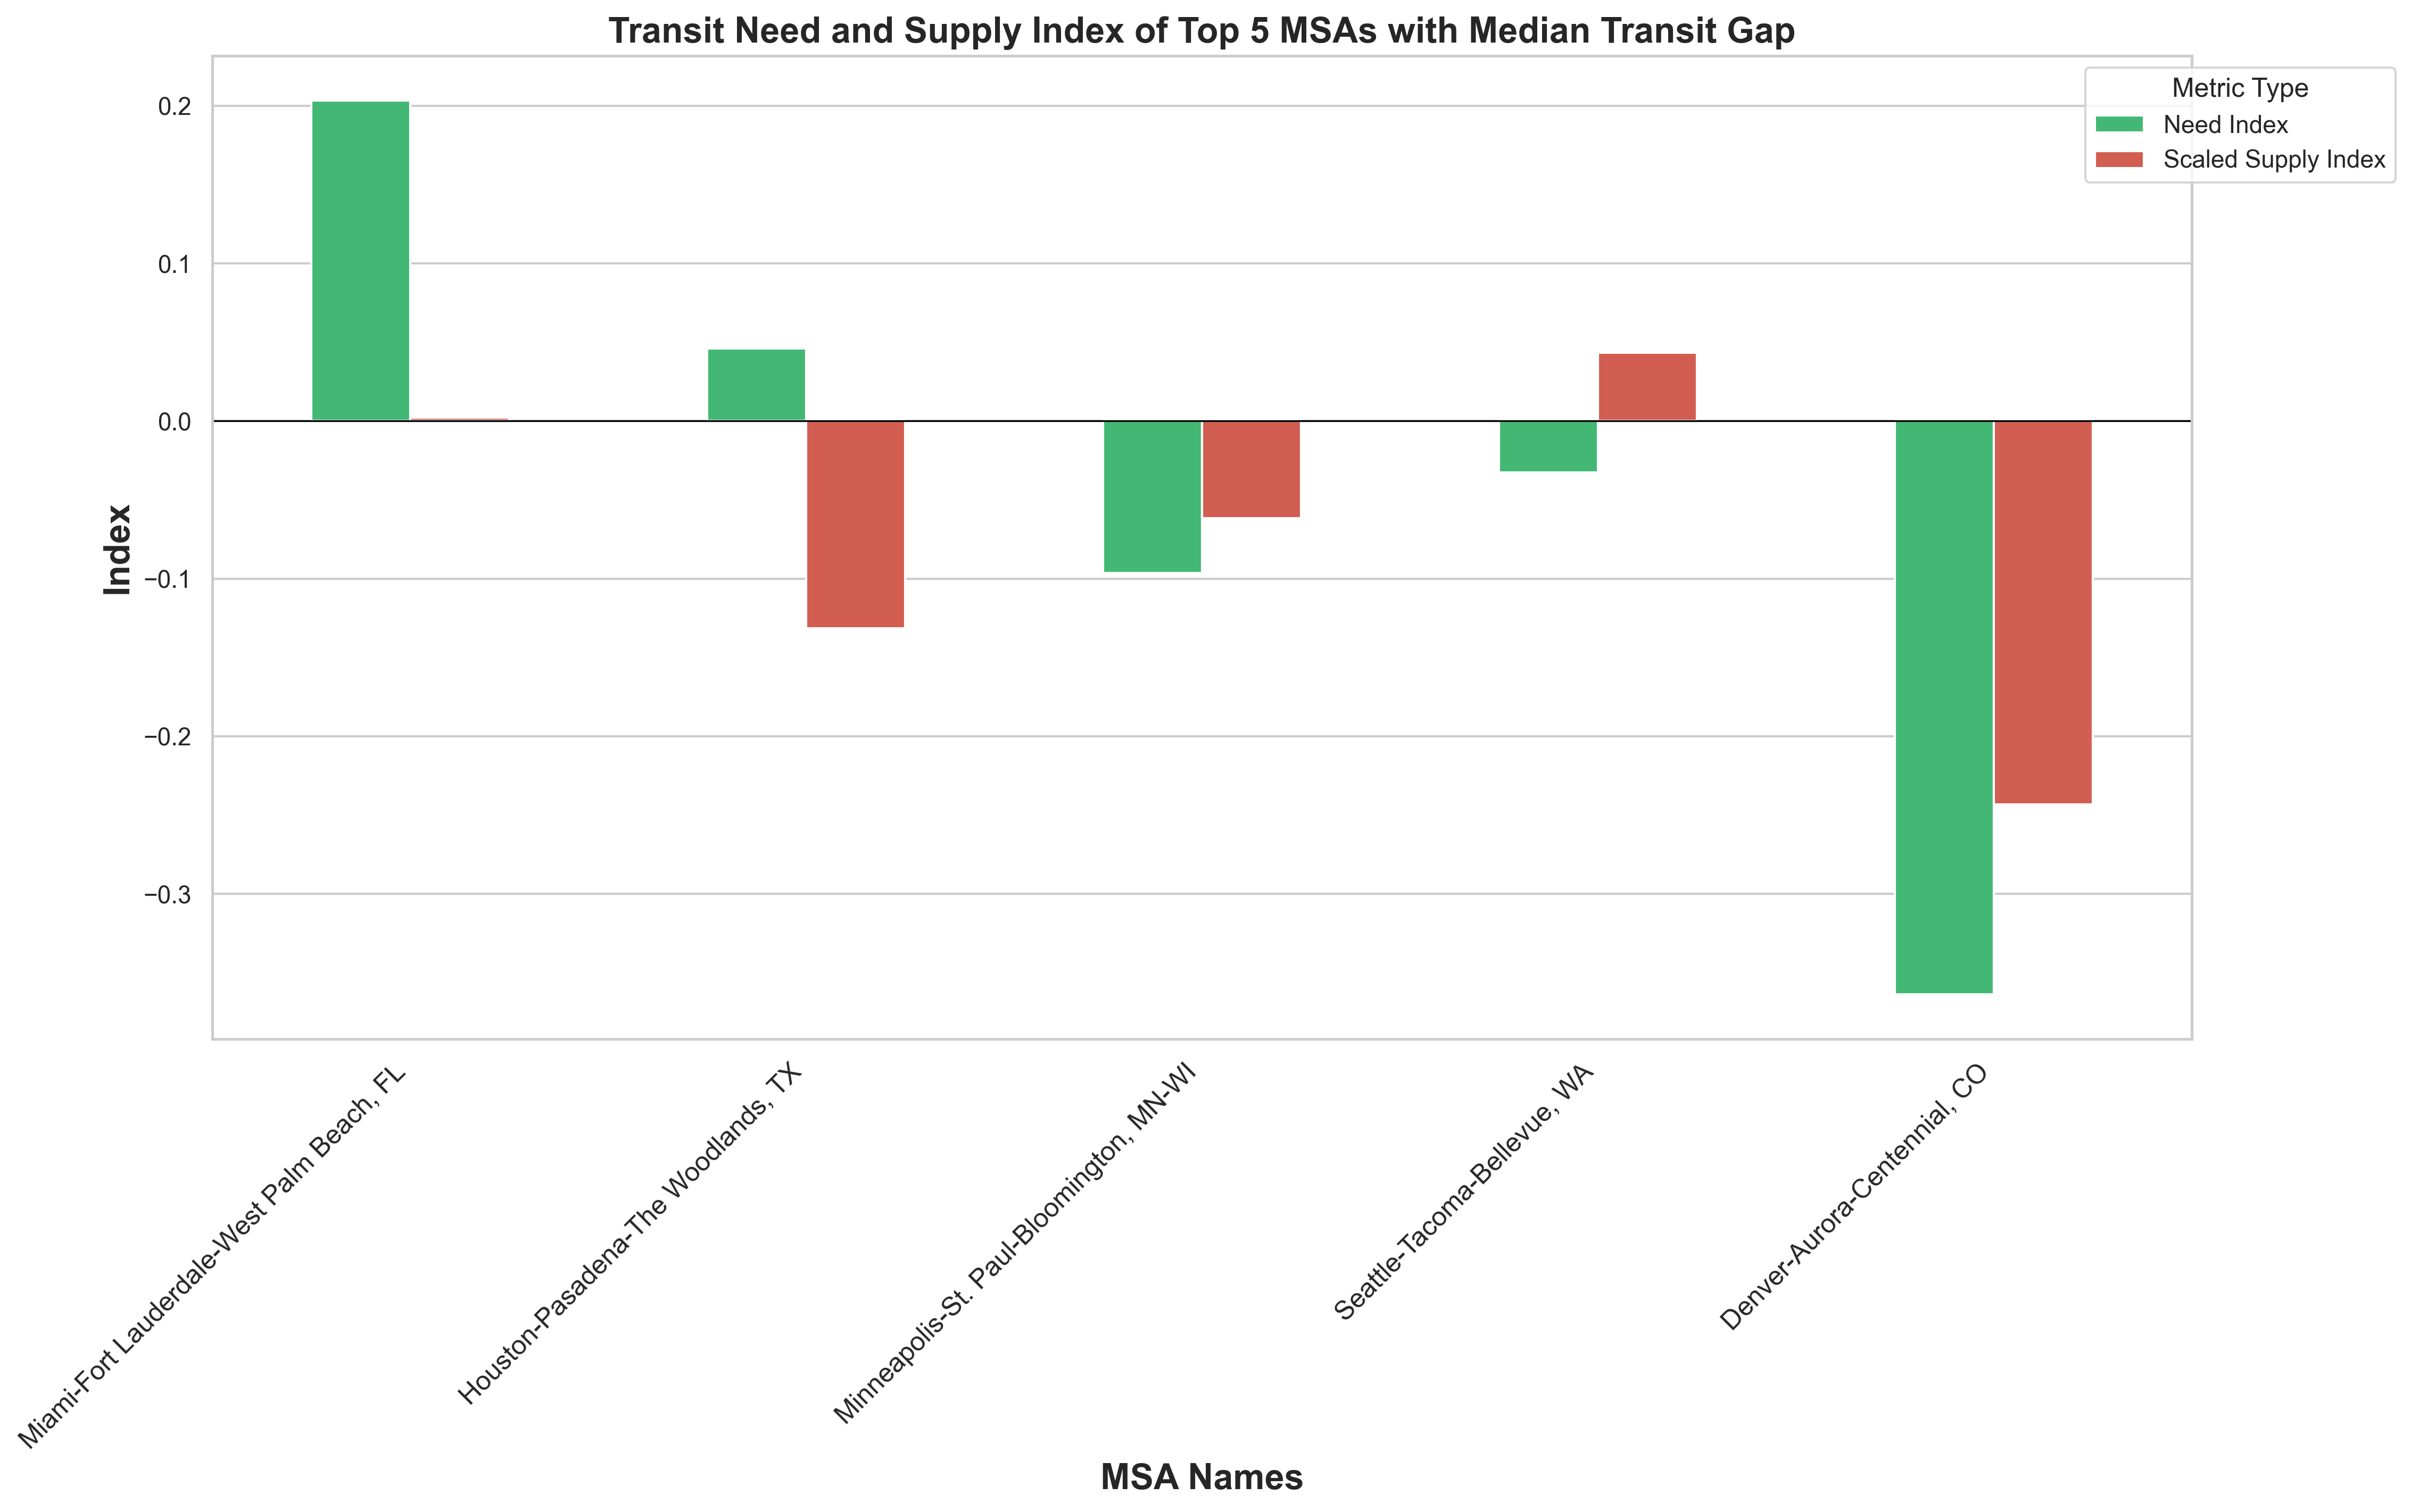

In [10]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

sorted_df = gap_df.sort_values(by='Transit Gap', ascending=False)

concat_df = pd.concat([sorted_df.iloc[7:12]]) #EDIT THIS

plot_df = concat_df.head().melt(
    id_vars="MSA_Name",
    value_vars=["Need Index", "Scaled Supply Index"],
    var_name="Metric",
    value_name="Value"
)

colors = {
    "Need Index": '#2ecc71',
    "Scaled Supply Index": '#e74c3c'
}

#Plot
plt.figure(figsize=(16, 8), dpi=300)
sns.barplot(data=plot_df, x='MSA_Name', y='Value', hue='Metric', palette=colors, width=0.5)


#Enhance readability
plt.axhline(0, color='black', linewidth=0.8) # Add a clear line at zero
plt.legend(
    title="Metric Type",
    loc="upper left",
    bbox_to_anchor=(0.94, 1)
)
plt.title("Transit Need and Supply Index of Top 5 MSAs with Median Transit Gap", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.xlabel('MSA Names', fontsize=16, fontweight='bold')
plt.ylabel('Index', fontsize=16, fontweight='bold')

plt.show()

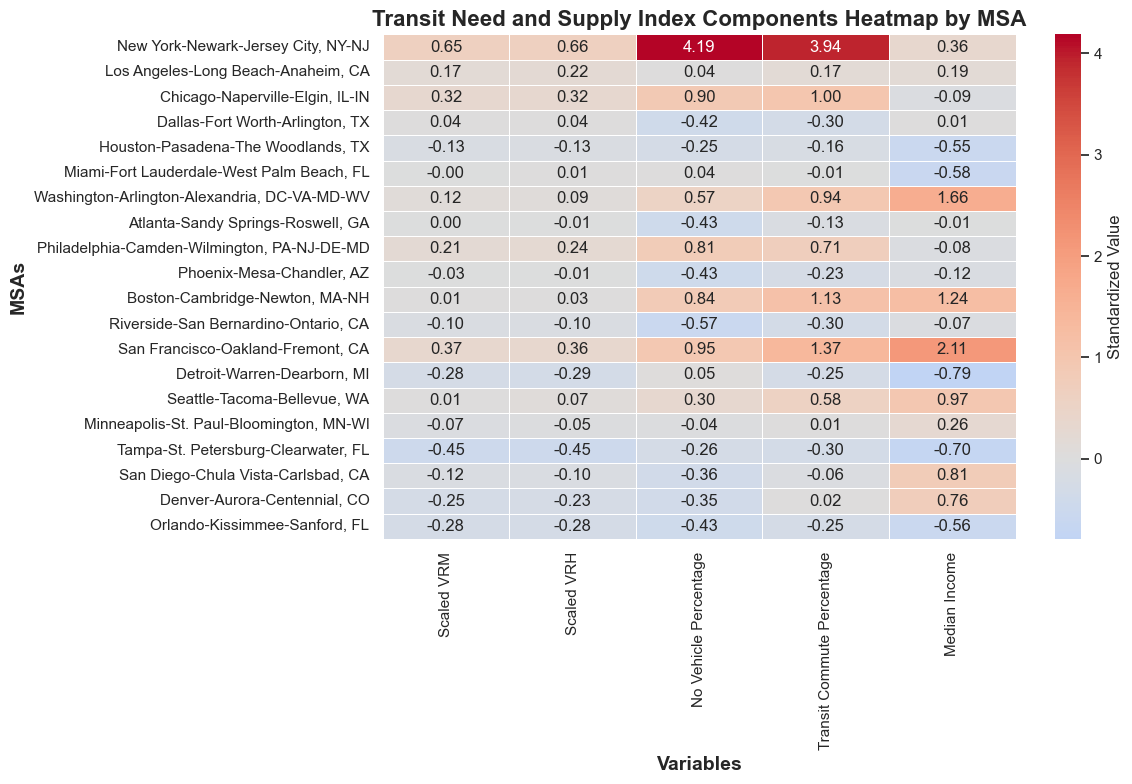

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set MSAs as index
df = pd.DataFrame({
    'MSAs': need_df['MSA_Name'],
    'Scaled VRM': var1,
    'Scaled VRH': var2,
    'No Vehicle Percentage': var3,
    'Transit Commute Percentage': var4,
    'Median Income': var5
})

heatmap_df = df.set_index('MSAs')

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    heatmap_df,
    annot=True,        # show values in cells
    cmap='coolwarm',   # red-blue color scheme
    center=0,          # makes zero centered (important for negative/positive)
    linewidths=0.5,    # lines between cells
    fmt=".2f",         # 2 decimal places
    cbar_kws={'label': 'Standardized Value'}
)

plt.title("Transit Need and Supply Index Components Heatmap by MSA", fontsize=16, fontweight='bold')
plt.xlabel("Variables", fontsize=14, fontweight='bold')
plt.ylabel("MSAs", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
